In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.models import resnet18, ResNet18_Weights
import pandas as pd
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import time
import warnings

warnings.filterwarnings("ignore")

In [4]:
data_dir = r"C:\Pytorch_project\project_shop\NewDatSet\umkm\static\product_images"
metadata_path = r"C:\Pytorch_project\project_shop\NewDatSet\umkm\static\product_images\metadata.csv"
batch_size = 32
num_epochs = 15
feature_dim = 512
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
class UMKMProductDataset(Dataset):
    def __init__(self, root_dir, metadata_path, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.metadata_df = pd.read_csv(metadata_path)
        
        # Ekstrak kelas dari file_path (misal: 'bed\bed_0.png' -> 'bed')
        self.metadata_df['class'] = self.metadata_df['file_path'].apply(
            lambda x: x.split('\\')[0] if '\\' in x else x.split('/')[0]
        )
        
        self.classes = sorted(self.metadata_df['class'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        self.samples = []
        for _, row in self.metadata_df.iterrows():
            img_path = os.path.join(root_dir, row['file_path'])
            if os.path.exists(img_path):
                class_idx = self.class_to_idx[row['class']]
                self.samples.append((img_path, class_idx, row.to_dict()))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label, metadata = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, metadata


In [5]:
def custom_collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    metadatas = [item[2] for item in batch]
    return images, labels, metadatas

In [6]:
print("Memuat dataset...")
try:
    full_dataset = UMKMProductDataset(
        root_dir=data_dir,
        metadata_path=metadata_path,
        transform=transform
    )
    print("Dataset berhasil dimuat!")
    print(f"Jumlah sampel: {len(full_dataset)}")
    print(f"Kelas: {full_dataset.classes}")
except Exception as e:
    print(f"Error saat memuat dataset: {e}")
    raise

# Bagi dataset
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

Memuat dataset...
Dataset berhasil dimuat!
Jumlah sampel: 9000
Kelas: ['bed', 'chair', 'sofa', 'table']


In [7]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=custom_collate_fn)

print(f"\nInformasi Pembagian Dataset:")
print(f"Total samples: {total_size}")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Informasi Pembagian Dataset:
Total samples: 9000
Train samples: 7200
Validation samples: 1350
Test samples: 450


In [8]:
class VisualPreferenceExtractor(nn.Module):
    def __init__(self, num_classes=4, feature_dim=512):
        super(VisualPreferenceExtractor, self).__init__()
        
        # Gunakan ResNet18 pretrained
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        
        # Freeze layer awal
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        # Unfreeze layer akhir
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        
        # Modifikasi fully connected layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        
        # Head untuk ekstraksi fitur
        self.feature_extractor = nn.Sequential(
            nn.Linear(in_features, feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )
        
        # Head untuk klasifikasi
        self.classifier = nn.Linear(feature_dim, num_classes)
        
    def forward(self, x):
        features = self.backbone(x)
        visual_features = self.feature_extractor(features)
        logits = self.classifier(visual_features)
        return visual_features, logits

model = VisualPreferenceExtractor(num_classes=len(full_dataset.classes)).to(device)
print(f"\nModel berhasil dibuat di perangkat {device}!")



Model berhasil dibuat di perangkat cuda!


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # Phase training
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels, _ in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            _, outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)
        
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # Phase validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels, _ in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                _, outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)
        
        epoch_val_loss = val_loss / total_val
        epoch_val_acc = correct_val / total_val
        
        # Update scheduler
        scheduler.step()
        
        # Update best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), 'resnet18s_best_model.pth')
        
        # Simpan history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        
        epoch_time = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] {epoch_time:.1f}s")
        print(f"  Train: Loss={epoch_train_loss:.4f}, Acc={epoch_train_acc:.4f}")
        print(f"  Val:   Loss={epoch_val_loss:.4f}, Acc={epoch_val_acc:.4f}")
    
    print(f"\nPelatihan selesai! Akurasi validasi terbaik: {best_val_acc:.4f}")
    return history

In [11]:
print("\nMemulai pelatihan model...")
history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs
)


Memulai pelatihan model...
Epoch [1/15] 74.3s
  Train: Loss=0.1224, Acc=0.9614
  Val:   Loss=0.0497, Acc=0.9867
Epoch [2/15] 65.5s
  Train: Loss=0.0556, Acc=0.9854
  Val:   Loss=0.0454, Acc=0.9859
Epoch [3/15] 69.2s
  Train: Loss=0.0533, Acc=0.9871
  Val:   Loss=0.0966, Acc=0.9763
Epoch [4/15] 67.5s
  Train: Loss=0.0232, Acc=0.9933
  Val:   Loss=0.0301, Acc=0.9926
Epoch [5/15] 66.1s
  Train: Loss=0.0286, Acc=0.9924
  Val:   Loss=0.0353, Acc=0.9904
Epoch [6/15] 65.5s
  Train: Loss=0.0117, Acc=0.9964
  Val:   Loss=0.0311, Acc=0.9926
Epoch [7/15] 66.3s
  Train: Loss=0.0077, Acc=0.9981
  Val:   Loss=0.0265, Acc=0.9919
Epoch [8/15] 66.2s
  Train: Loss=0.0065, Acc=0.9985
  Val:   Loss=0.0246, Acc=0.9926
Epoch [9/15] 66.7s
  Train: Loss=0.0083, Acc=0.9981
  Val:   Loss=0.0274, Acc=0.9896
Epoch [10/15] 66.6s
  Train: Loss=0.0040, Acc=0.9992
  Val:   Loss=0.0266, Acc=0.9933
Epoch [11/15] 66.3s
  Train: Loss=0.0029, Acc=0.9990
  Val:   Loss=0.0261, Acc=0.9926
Epoch [12/15] 66.5s
  Train: Loss=0

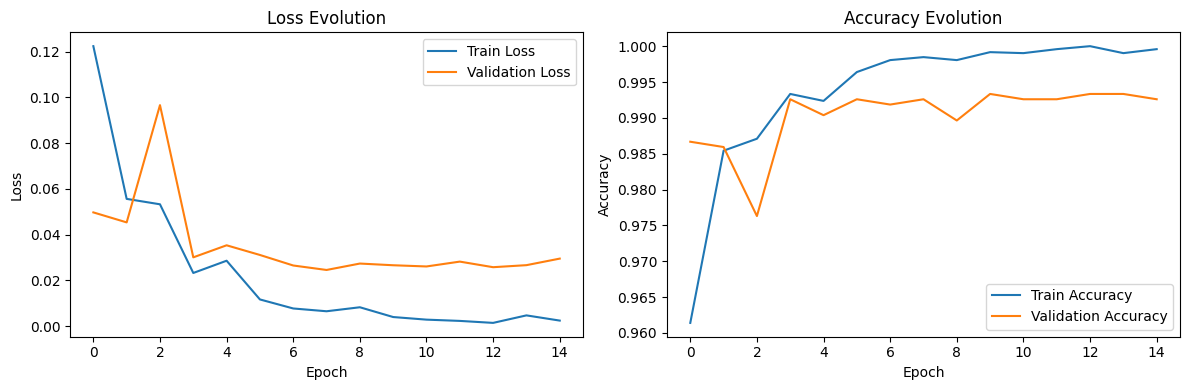

In [12]:
# Plot hasil pelatihan
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('resnet18s_training_history.png')
plt.show()


In [13]:
def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_features = []
    all_metadata = []
    
    with torch.no_grad():
        for inputs, labels, metadatas in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            features, outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_features.extend(features.cpu().numpy())
            all_metadata.extend(metadatas)  # Ini sudah list dari dictionary
    
    # Classification report
    class_names = full_dataset.classes
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Simpan fitur untuk rekomendasi
    feature_dict = {}
    for i, (feat, meta) in enumerate(zip(all_features, all_metadata)):
        img_name = os.path.basename(meta['file_path'])
        feature_dict[img_name] = {
            'features': feat,
            'category': class_names[all_labels[i]],
            'type': meta['type'],
            'style': meta['style'],
            'color': meta['color'],
            'material': meta['material'],
            'shape': meta['shape'],
            'details': meta['details'],
            'room_type': meta['room_type'],
            'price_range': meta['price_range'],
            'file_path': meta['file_path']
        }
    
    torch.save(feature_dict, 'resnet18s_product_features.pth')
    print("Product features saved to 'product_features.pth'")
    
    return all_features, all_labels, all_metadata

In [14]:
print("\nEvaluasi model pada test set...")
test_features, test_labels, test_metadata = evaluate_model(model, test_loader)


Evaluasi model pada test set...

Classification Report:
              precision    recall  f1-score   support

         bed       0.97      1.00      0.98       117
       chair       0.99      0.99      0.99       122
        sofa       0.99      0.97      0.98        99
       table       1.00      0.98      0.99       112

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450

Product features saved to 'product_features.pth'


In [15]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx': full_dataset.class_to_idx,
    'classes': full_dataset.classes
}, 'resnet18s_umkm_visual_model.pth')
print("Model saved to 'umkm_visual_model.pth'")

Model saved to 'umkm_visual_model.pth'



Membuat visualisasi fitur...


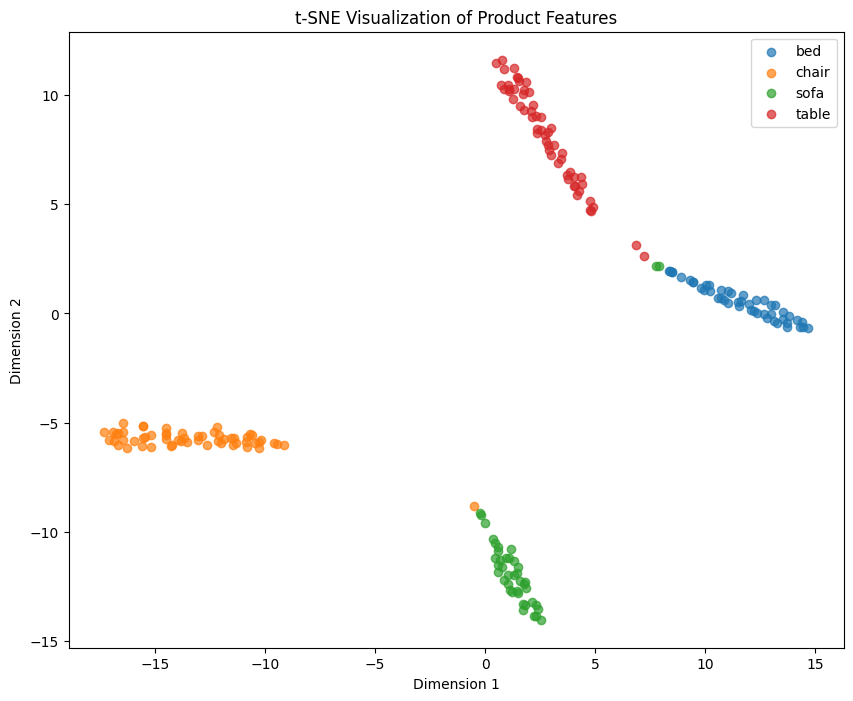

In [16]:
print("\nMembuat visualisasi fitur...")
if len(test_features) > 0:
    num_visualize = min(200, len(test_features))
    features_subset = np.array(test_features[:num_visualize])
    labels_subset = np.array(test_labels[:num_visualize])
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, num_visualize-1))
    features_2d = tsne.fit_transform(features_subset)
    
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(full_dataset.classes):
        indices = np.where(labels_subset == i)
        if len(indices[0]) > 0:
            plt.scatter(features_2d[indices, 0], features_2d[indices, 1], 
                        label=class_name, alpha=0.7)
            
    plt.title('t-SNE Visualization of Product Features')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.savefig('resnet18s_feature_visualization.png')
    plt.show()
else:
    print("Tidak ada fitur yang dapat divisualisasikan")

In [17]:
if os.path.exists('product_features.pth') and os.path.getsize('product_features.pth') > 0:
    class ProductRecommender:
        def __init__(self, feature_file):
            # Gunakan weights_only=False untuk memuat file fitur
            self.feature_dict = torch.load(feature_file, weights_only=False)
            self.product_ids = list(self.feature_dict.keys())
            self.features = np.array([self.feature_dict[pid]['features'] for pid in self.product_ids])
            
        def recommend(self, query_feature, top_k=5):
            similarities = cosine_similarity([query_feature], self.features)[0]
            top_indices = similarities.argsort()[::-1][:top_k]
            
            results = []
            for idx in top_indices:
                pid = self.product_ids[idx]
                product_info = self.feature_dict[pid]
                results.append({
                    'image_name': pid,
                    'similarity': similarities[idx],
                    'category': product_info['category'],
                    'type': product_info['type'],
                    'style': product_info['style'],
                    'color': product_info['color'],
                    'material': product_info['material'],
                    'price_range': product_info['price_range']
                })
            
            return results

    # Inisialisasi recommender
    recommender = ProductRecommender('product_features.pth')
    
    if len(recommender.feature_dict) > 0:
        sample_product_id = list(recommender.feature_dict.keys())[0]
        sample_feature = recommender.feature_dict[sample_product_id]['features']
        recommendations = recommender.recommend(sample_feature)

        print(f"\nRekomendasi untuk produk {sample_product_id}:")
        for i, rec in enumerate(recommendations):
            print(f"{i+1}. Gambar: {rec['image_name']}")
            print(f"   Similarity: {rec['similarity']:.4f}")
            print(f"   Kategori: {rec['category']}")
            print(f"   Tipe: {rec['type']}, Gaya: {rec['style']}")
            print(f"   Warna: {rec['color']}, Material: {rec['material']}")
            print(f"   Rentang Harga: {rec['price_range']}\n")
    else:
        print("\nTidak ada produk dalam sistem rekomendasi")
else:
    print("\nFile fitur produk tidak ditemukan atau kosong, sistem rekomendasi dilewati")


Rekomendasi untuk produk sofa_2344.png:
1. Gambar: sofa_2344.png
   Similarity: 1.0000
   Kategori: sofa
   Tipe: sofa, Gaya: gothic
   Warna: terra, Material: leather
   Rentang Harga: standard

2. Gambar: sofa_3328.png
   Similarity: 0.9997
   Kategori: sofa
   Tipe: sofa, Gaya: classic
   Warna: teal, Material: suede
   Rentang Harga: elite

3. Gambar: sofa_4007.png
   Similarity: 0.9997
   Kategori: sofa
   Tipe: sofa, Gaya: brutalist
   Warna: ivory, Material: suede
   Rentang Harga: luxury

4. Gambar: sofa_3986.png
   Similarity: 0.9997
   Kategori: sofa
   Tipe: sofa, Gaya: japanese
   Warna: ivory, Material: canvas
   Rentang Harga: premium

5. Gambar: sofa_2918.png
   Similarity: 0.9996
   Kategori: sofa
   Tipe: sofa, Gaya: retro
   Warna: gray, Material: silk
   Rentang Harga: standard



In [18]:
def extract_features(image_path, model, device, transform):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        features, _ = model(image)
    
    return features.squeeze().cpu().numpy()

In [19]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx': full_dataset.class_to_idx,
    'transform': transform,
    'feature_dim': feature_dim,
    'classes': full_dataset.classes
}, 'resnet18s_umkm_visual_extractor.pth')

print("\nModel siap produksi disimpan sebagai 'umkm_visual_extractor.pth'")
print("Proses selesai!")


Model siap produksi disimpan sebagai 'umkm_visual_extractor.pth'
Proses selesai!


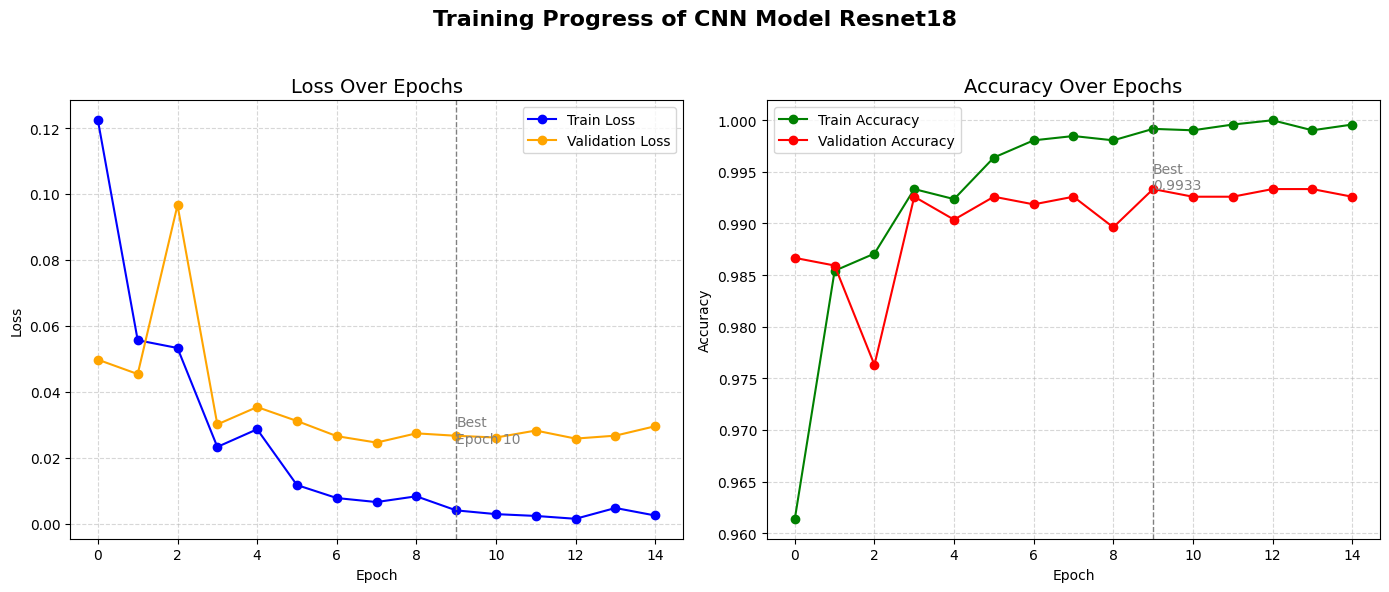

In [20]:
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
best_val_acc = max(history['val_acc'])

plt.figure(figsize=(14, 6))
plt.suptitle("Training Progress of CNN Model Resnet18", fontsize=16, fontweight='bold')

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.plot(history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Loss Over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.axvline(best_epoch-1, color='gray', linestyle='--', linewidth=1, label=f'Best Epoch ({best_epoch})')
plt.text(best_epoch-1, min(history['val_loss']), f'Best\nEpoch {best_epoch}', color='gray')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='green', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', color='red', marker='o')
plt.title('Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.axvline(best_epoch-1, color='gray', linestyle='--', linewidth=1)
plt.text(best_epoch-1, best_val_acc, f'Best\n{best_val_acc:.4f}', color='gray')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Resnet18s_training_history_detailed.png')
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, test_loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_features = []
    all_metadata = []

    with torch.no_grad():
        for inputs, labels, metadatas in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            features, outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_features.extend(features.cpu().numpy())
            all_metadata.extend(metadatas)

    # Classification report
    class_names = full_dataset.classes
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Simpan fitur untuk rekomendasi
    feature_dict = {}
    for i, (feat, meta) in enumerate(zip(all_features, all_metadata)):
        img_name = os.path.basename(meta['file_path'])
        feature_dict[img_name] = {
            'features': feat,
            'category': class_names[all_labels[i]],
            'type': meta['type'],
            'style': meta['style'],
            'color': meta['color'],
            'material': meta['material'],
            'shape': meta['shape'],
            'details': meta['details'],
            'room_type': meta['room_type'],
            'price_range': meta['price_range'],
            'file_path': meta['file_path']
        }

    torch.save(feature_dict, 'product_features.pth')
    print("Product features saved to '_Resnet_product_features.pth'")

    # Tambahkan confusion matrix (bisa juga dipisahkan di luar jika mau)
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix: UMKM Product Classification")
    plt.tight_layout()
    plt.savefig("Resnet_confusion_matrix_umkm.png")
    plt.show()

    return all_features, all_labels, all_metadata, all_preds


Classification Report:
              precision    recall  f1-score   support

         bed       0.97      1.00      0.98       117
       chair       0.99      0.99      0.99       122
        sofa       0.99      0.97      0.98        99
       table       1.00      0.98      0.99       112

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450

Product features saved to '_Resnet_product_features.pth'


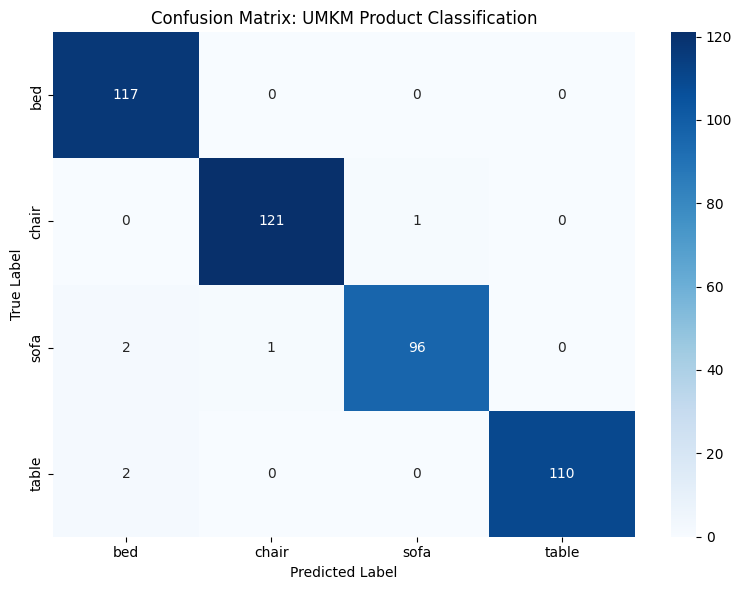

In [22]:
test_features, test_labels, test_metadata, test_preds = evaluate_model(model, test_loader)